In [3]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import numpy as np


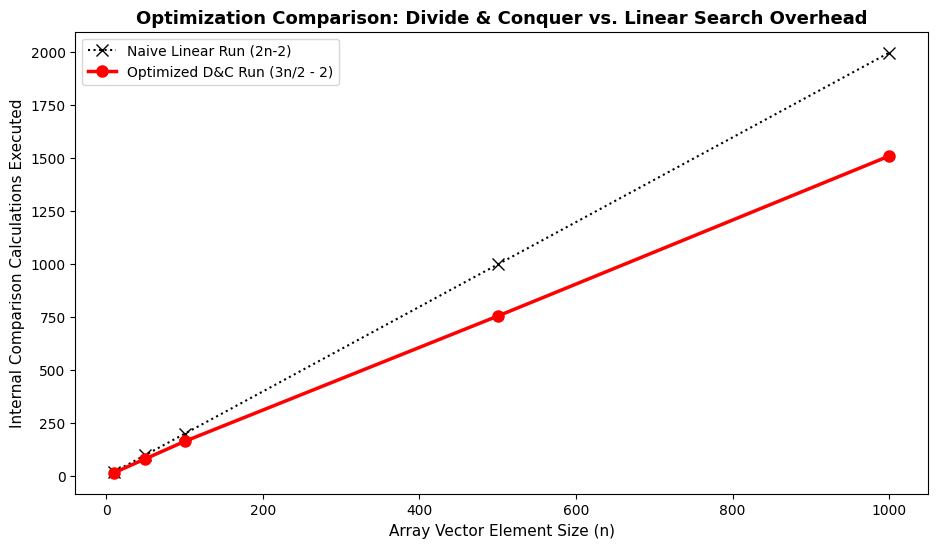

In [5]:

def min_max_dc(arr, low, high):
    global comparison_count
    if low == high: return arr[low], arr[low]
    if high == low + 1:
        comparison_count += 1
        return (arr[low], arr[high]) if arr[low] < arr[high] else (arr[high], arr[low])
    mid = (low + high) // 2
    lmin, lmax = min_max_dc(arr, low, mid)
    rmin, rmax = min_max_dc(arr, mid + 1, high)
    comparison_count += 2
    return min(lmin, rmin), max(lmax, rmax)

def min_max_naive(arr):
    mn, mx = arr[0], arr[0]
    comps = 0
    for x in arr[1:]:
        comps += 2
        if x < mn: mn = x
        elif x > mx: mx = x
    return comps

# Evaluate Scaling Optimization Costs
sizes_exp5 = [10, 50, 100, 500, 1000]
dc_operations, naive_operations = [], []

for size in sizes_exp5:
    test_arr = [random.randint(1, 100000) for _ in range(size)]
    comparison_count = 0
    min_max_dc(test_arr, 0, len(test_arr) - 1)
    dc_operations.append(comparison_count)
    naive_operations.append(min_max_naive(test_arr))

# Plot performance delta lines
plt.figure(figsize=(11, 6))
plt.plot(sizes_exp5, naive_operations, marker='x', markersize=8, color='black', linestyle=':', label='Naive Linear Run (2n-2)')
plt.plot(sizes_exp5, dc_operations, marker='o', markersize=8, color='red', linewidth=2.5, label='Optimized D&C Run (3n/2 - 2)')

plt.title('Optimization Comparison: Divide & Conquer vs. Linear Search Overhead', fontsize=13, fontweight='bold')
plt.xlabel('Array Vector Element Size (n)', fontsize=11)
plt.ylabel('Internal Comparison Calculations Executed', fontsize=11)
plt.legend()
plt.show()